In [1]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cell2location
import scvi
import os
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
import seaborn as sns
import time
import gc
gc.collect()
import torch


/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel
from sklearn.metrics.cluster import adjusted_rand_score as ARI
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from cell2location.models import Cell2location

### Reference signature generation using single-cell dataset

In [3]:
data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/SC/CID4290_SC_filtered.h5ad"
results_folder = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/final_outputs/ER+/"

ref_run_name = f'{results_folder}reference_signatures'
run_name = f'{results_folder}cell2location_map'
cancer: celltype_minor
celltype_name = "celltype_minor"



/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


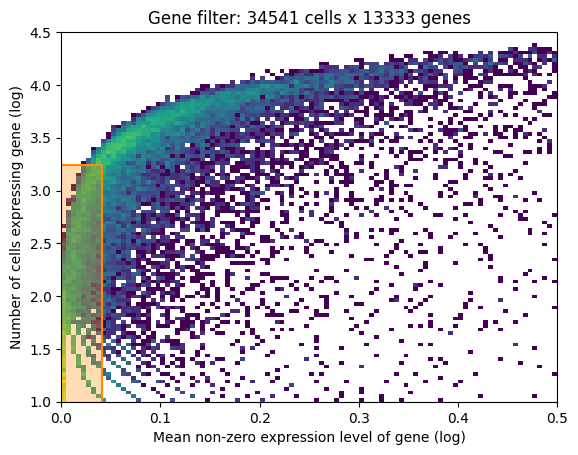

In [4]:
adata= sc.read_h5ad(data_path)
df = adata.obs[celltype_name]

adata.var_names_make_unique()
adata_ref = adata.copy()

selected = filter_genes(adata_ref, cell_count_cutoff = 5, cell_percentage_cutoff2 = 0.05, nonz_mean_cutoff = 1.1)
adata_ref = adata_ref[:, selected].copy()

In [5]:
RegressionModel.setup_anndata(adata = adata_ref, labels_key = celltype_name)
mod = RegressionModel(adata_ref)

mod.view_anndata_setup()


mod.train(max_epochs = 200, train_size = 1, batch_size = 8, use_gpu = True)
adata_ref = mod.export_posterior(
adata_ref, sample_kwargs={'num_samples': 4000,  'use_gpu': True}
)
mod.save(f"{ref_run_name}", overwrite=True)
adata_file = f"{ref_run_name}/sc_breast_cancer.h5ad"
adata_ref.write(adata_file)

/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
CUDA backend failed to initialize: Found CUDA version 12010, but JAX was built against version 12020, which is newer. The copy of CUDA that is installed must be at least as new as the version against which JAX was built. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': 'celltype_minor',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 34541 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  22   │
│          n_vars          │ 13333 │
└──────────────────────────┴───────┘

...

Epoch 200/200: 100%|█| 200/200 [28:02:07<00:00, 183.59s/it, v_num=1, elbo_train=

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|█| 200/200 [28:02:07<00:00, 504.64s/it, v_num=1, elbo_train=

/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(



Sampling global variables, sample: 100%|██████████████████████████████████| 3999/3999 [00:35<00:00, 113.02it/s]


### Cell2Location on Spatial data

In [6]:
adata_ref = anndata.read_h5ad(f"{ref_run_name}/sc_breast_cancer.h5ad")

if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}' 
                            for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}' 
                            for i in adata_ref.uns['mod']['factor_names']]].copy()


inf_aver.columns = adata_ref.uns['mod']['factor_names']
reg_path = f'{results_folder}regression_model/'
torch.cuda.empty_cache()


In [7]:
adata = anndata.read_h5ad(f"{ref_run_name}/sc_breast_cancer.h5ad")
sc.pp.calculate_qc_metrics(adata, inplace = True)
adata.obs.index.name = 'spot_id'

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/simulator_outputs/ER+/"

adata_vis = sc.read_h5ad(data_path + "simulated_gene_expression_average.h5ad")

adata_vis.obs_names_make_unique()
adata_vis.var_names = pd.Categorical(adata_vis.var_names).astype(str)
adata_vis.var_names_make_unique()


#adata_vis = adata.copy()
adata_vis.raw = adata_vis
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

In [8]:
# prepare anndata for cell2location model

Cell2location.setup_anndata(adata = adata_vis)
mod.view_anndata_setup()


mod = cell2location.models.Cell2location(adata_vis, cell_state_df = inf_aver, N_cells_per_location = 30,detection_alpha = 200)
mod.train(max_epochs = 5000, batch_size = None, train_size = 1,use_gpu = True)
adata_vis = mod.export_posterior(
adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs, 'use_gpu': True}
)
adata_file = f"{run_name}/st.h5ad"
adata_vis.write(adata_file)
mod.export_posterior(adata_vis)

Anndata setup with scvi-tools version 1.0.4.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': 'celltype_minor',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 34541 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  22   │
│          n_vars          │ 13333 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

...

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 5000/5000: 100%|████████████████████████| 5000/5000 [10:16<00:00,  8.11it/s, v_num=1, elbo_train=9.24e+6]

/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/model/base/_pyromixin.py:388: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(



Sampling global variables, sample: 100%|█████████████████████████████████████| 999/999 [00:23<00:00, 41.63it/s]


FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/final_outputs/ER+/cell2location_map/st.h5ad', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [10]:
df_ctp = adata_vis.obsm["q05_cell_abundance_w_sf"]
df_ctp = df_ctp.div(df_ctp.sum(axis = 1), axis = 0)
df_ctp.sum(axis = 1)

In [12]:
df_ctp.to_csv(results_folder + "output_cell2Location.csv", index = True)